# Tiny MNIST Latent Diffusion with Text Guidance

This notebook trains a **minimal latent diffusion model** on MNIST.

Pipeline:

```text
MNIST image -> Autoencoder encoder -> latent z
latent z + noise + text condition -> denoiser predicts noise
sample noise -> denoise in latent space -> Autoencoder decoder -> image
```

For simplicity, text guidance is implemented with prompts like:

```python
"digit 0", "digit 1", ..., "digit 9"
```

Instead of CLIP, we use a small learned embedding table for these 10 text prompts. This keeps the notebook short and easy to run.


In [1]:
import math
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

torch.manual_seed(42)
random.seed(42)


cuda


## 1. Load MNIST

Images are normalized to `[-1, 1]`, which is common for generative models.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Keep it small for a quick educational run.
subset_size = 10_000
train_ds = torch.utils.data.Subset(train_ds, range(subset_size))

loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)


## 2. Tiny Autoencoder

Latent diffusion does not denoise pixels directly. It denoises a compressed latent representation.

Here, the latent shape is:

```text
image:  1 x 28 x 28
latent: 8 x 7 x 7
```


In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_ch=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 14x14
            nn.SiLU(),
            nn.Conv2d(32, latent_ch, 3, stride=2, padding=1),  # 7x7
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_ch, 32, 4, stride=2, padding=1),  # 14x14
            nn.SiLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),  # 28x28
            nn.Tanh(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))


ae = Autoencoder().to(device)
opt_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)


AE epoch 1: loss=0.3489
AE epoch 2: loss=0.0663
AE epoch 3: loss=0.0318


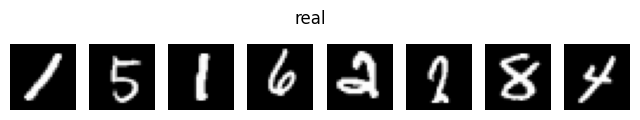

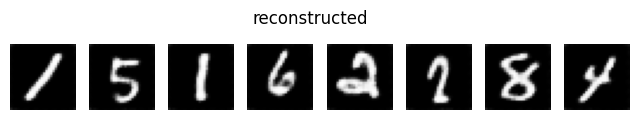

In [4]:
def show_images(x, title=None):
    x = (x.detach().cpu() + 1) / 2
    fig, axes = plt.subplots(1, len(x), figsize=(len(x), 1.4))
    if len(x) == 1:
        axes = [axes]
    for ax, img in zip(axes, x):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.show()


def train_autoencoder(epochs=3):
    ae.train()
    for epoch in range(epochs):
        total = 0.0
        for x, _ in loader:
            x = x.to(device)
            x_hat = ae(x)
            loss = F.mse_loss(x_hat, x)

            opt_ae.zero_grad()
            loss.backward()
            opt_ae.step()

            total += loss.item()
        print(f"AE epoch {epoch + 1}: loss={total / len(loader):.4f}")


train_autoencoder(epochs=3)

x, _ = next(iter(loader))
x = x[:8].to(device)
with torch.no_grad():
    x_hat = ae(x)
show_images(x, "real")
show_images(x_hat, "reconstructed")


## 3. Diffusion Utilities

The forward process adds Gaussian noise to the latent:

$$z_t = \sqrt{\bar\alpha_t}z_0 + \sqrt{1 - \bar\alpha_t}\epsilon$$

The model learns to predict the noise `epsilon` from `(z_t, t, text_condition)`.


In [6]:
T = 100
betas = torch.linspace(1e-4, 2e-2, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def extract(v, t, x_shape):
    return v[t].view(-1, *([1] * (len(x_shape) - 1)))


def q_sample(z0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(z0)
    a_bar = extract(alpha_bars, t, z0.shape)
    return torch.sqrt(a_bar) * z0 + torch.sqrt(1 - a_bar) * noise


## 4. Conditional Latent Denoiser

The denoiser receives three things:

1. noisy latent `z_t`
2. timestep `t`
3. text prompt embedding, e.g. the embedding for `"digit 7"`

For classifier-free guidance, we randomly replace some labels with an unconditional token during training.


In [8]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb


class Denoiser(nn.Module):
    def __init__(self, latent_ch=8, cond_dim=64):
        super().__init__()
        self.time_emb = nn.Sequential(
            SinusoidalTimeEmbedding(cond_dim),
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU(),
        )

        # 10 digit prompts + 1 unconditional prompt
        self.text_emb = nn.Embedding(11, cond_dim)

        self.cond_proj = nn.Linear(cond_dim, latent_ch)

        self.net = nn.Sequential(
            nn.Conv2d(latent_ch, 64, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, latent_ch, 3, padding=1),
        )

    def forward(self, z_t, t, text_ids):
        cond = self.time_emb(t) + self.text_emb(text_ids)
        cond = self.cond_proj(cond).view(z_t.shape[0], z_t.shape[1], 1, 1)
        return self.net(z_t + cond)


denoiser = Denoiser().to(device)
opt_denoiser = torch.optim.Adam(denoiser.parameters(), lr=2e-4)


In [9]:
UNCOND_ID = 10

## 5. Train the Latent Diffusion Model

The autoencoder is frozen. The diffusion model trains only in latent space.


In [10]:
for p in ae.parameters():
    p.requires_grad = False
ae.eval()


def train_ldm(epochs=5, cond_drop_prob=0.1):
    denoiser.train()
    for epoch in range(epochs):
        total = 0.0
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            with torch.no_grad():
                z0 = ae.encode(x)

            t = torch.randint(0, T, (x.shape[0],), device=device)
            noise = torch.randn_like(z0)
            z_t = q_sample(z0, t, noise)

            # classifier-free training: sometimes remove the text condition
            text_ids = y.clone()
            drop_mask = torch.rand_like(text_ids.float()) < cond_drop_prob
            text_ids[drop_mask] = UNCOND_ID

            pred_noise = denoiser(z_t, t, text_ids)
            loss = F.mse_loss(pred_noise, noise)

            opt_denoiser.zero_grad()
            loss.backward()
            opt_denoiser.step()

            total += loss.item()
        print(f"LDM epoch {epoch + 1}: loss={total / len(loader):.4f}")


train_ldm(epochs=5)


LDM epoch 1: loss=0.9030
LDM epoch 2: loss=0.6434
LDM epoch 3: loss=0.5577
LDM epoch 4: loss=0.5314
LDM epoch 5: loss=0.5128


## 6. Text-Guided Sampling

Classifier-free guidance combines an unconditional prediction and a conditional prediction:

$$\epsilon = \epsilon_\text{uncond} + s(\epsilon_\text{cond} - \epsilon_\text{uncond})$$

where `s` is the guidance scale.


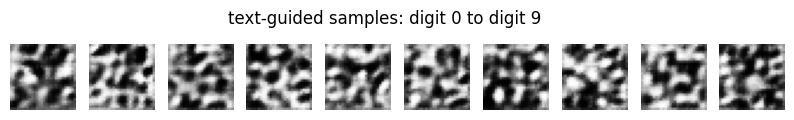

In [11]:
@torch.no_grad()
def p_sample(z, t, text_ids, guidance_scale=2.0):
    b = z.shape[0]
    t_batch = torch.full((b,), t, device=device, dtype=torch.long)

    eps_cond = denoiser(z, t_batch, text_ids)
    eps_uncond = denoiser(z, t_batch, torch.full_like(text_ids, UNCOND_ID))
    eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

    beta_t = betas[t]
    alpha_t = alphas[t]
    alpha_bar_t = alpha_bars[t]

    mean = (1 / torch.sqrt(alpha_t)) * (
        z - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps
    )

    if t == 0:
        return mean

    noise = torch.randn_like(z)
    return mean + torch.sqrt(beta_t) * noise


@torch.no_grad()
def sample_digits(digits, guidance_scale=2.0):
    denoiser.eval()
    ae.eval()

    text_ids = torch.tensor(digits, device=device, dtype=torch.long)
    z = torch.randn(len(digits), 8, 7, 7, device=device)

    for t in reversed(range(T)):
        z = p_sample(z, t, text_ids, guidance_scale=guidance_scale)

    x = ae.decode(z).clamp(-1, 1)
    return x


digits = list(range(10))
samples = sample_digits(digits, guidance_scale=2.5)
show_images(samples, title="text-guided samples: digit 0 to digit 9")


## Notes

- This is intentionally tiny and educational.
- The text encoder is not a real language model; it is a learned prompt embedding for the 10 digit prompts.
- A real latent diffusion model usually uses a much stronger autoencoder, a U-Net denoiser, and a pretrained text encoder such as CLIP or T5.
- Increase `subset_size`, `AE epochs`, and `LDM epochs` for better samples.
